In [ ]:
# Run this cell if the required packages are not already installed

!pip install -q tensorflow pandas numpy matplotlib seaborn scikit-learn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

import warnings
warnings.filterwarnings("ignore")

# For reproducible results
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


#### A) Data Manipulation

In [ ]:
url = "https://raw.githubusercontent.com/pmservice/wml-sample-models/master/spark/customer-satisfaction-prediction/data/WA_Fn%20UseC_%20Telco%20Customer%20Churn.csv"

df = pd.read_csv(url)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print("Shape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Shape of dataset:
(7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### Check Missing Values

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


#### Convert TotalCharges to numeric

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors="coerce")
print("Missing TotalCharges after conversion:")
print(df["TotalCharges"].isnull().sum())

Missing TotalCharges after conversion:
11


#### fill missing null values with median

In [ ]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

print("Missing values after treatment:")
print(df.isnull().sum().sum())

#### A(a) Total number of male customers

In [ ]:
male_customers = df[df["gender"] == "Male"]

print("Total number of male customers:", len(male_customers))

Total number of male customers: 3555


In [ ]:
print("Total male customers:", (df["gender"] == "Male").sum())

Total male customers: 3555


#### A(b) Total customers whose Internet Service is DSL

In [ ]:
dsl_customers = df[df["InternetService"] == "DSL"]

print("Total number of customers with DSL Internet Service:",
      len(dsl_customers))

Total number of customers with DSL Internet Service: 2421


#### A(c) Female senior citizens whose Payment Method is Mailed check

In [ ]:
new_customer = df[
    (df["gender"] == "Female") &
    (df["SeniorCitizen"] == 1) &
    (df["PaymentMethod"] == "Mailed check")
]

print("Female senior citizens using Mailed check:")
print(new_customer.shape)

display(new_customer.head())

Female senior citizens using Mailed check:
(50, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
139,0390-DCFDQ,Female,1,Yes,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,70.45,70.45,Yes
176,2656-FMOKZ,Female,1,No,No,15,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.45,1145.70,Yes
267,3197-ARFOY,Female,1,No,No,19,Yes,No,Fiber optic,Yes,...,No,Yes,Yes,Yes,Month-to-month,Yes,Mailed check,105.00,2007.25,No
451,5760-WRAHC,Female,1,No,No,22,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,Month-to-month,Yes,Mailed check,69.75,1545.40,No
470,4933-IKULF,Female,1,No,No,17,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.65,330.60,No


#### A(d) Customers with tenure < 10 OR TotalCharges < 500

In [ ]:
new_customer = df[
    (df["tenure"] < 10) |
    (df["TotalCharges"] < 500)
]

print("Customers satisfying the condition:")
print(new_customer.shape)

display(new_customer.head())

Customers satisfying the condition:
(2233, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No


#### B(a) DATA VISUALIZATION
B(a) Pie chart — Churn distribution

Churn
No     5174
Yes    1869
Name: count, dtype: int64


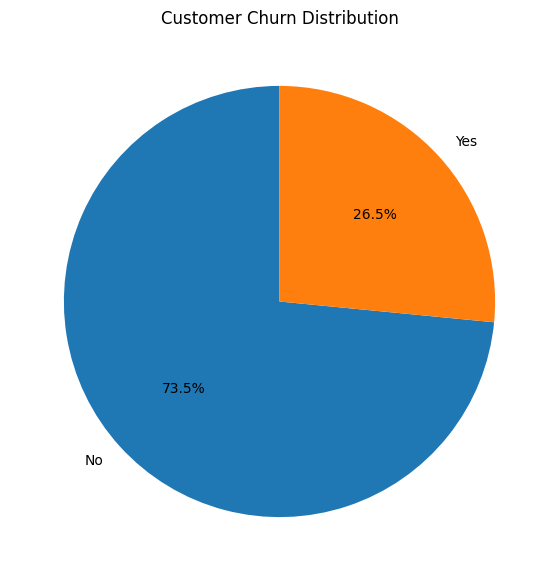

In [ ]:
churn_counts = df["Churn"].value_counts()

print(churn_counts)

plt.figure(figsize=(7, 7))

plt.pie(
    churn_counts.values,
    labels=churn_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Churn Distribution")
plt.show()

#### B(b) Bar plot — Internet Service distribution


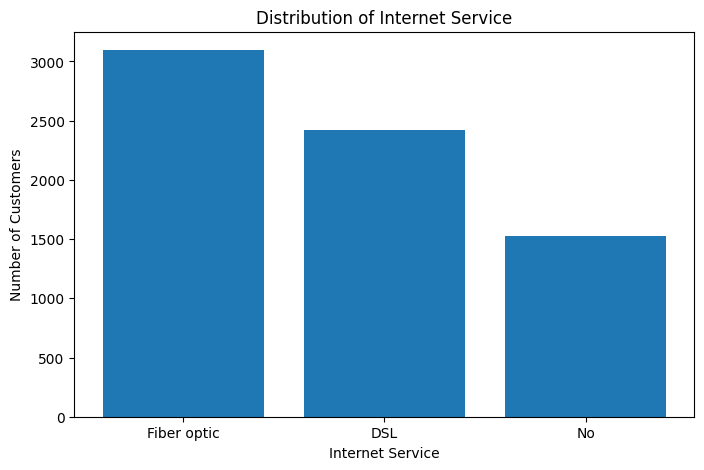

In [ ]:
internet_counts = df["InternetService"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    internet_counts.index,
    internet_counts.values
)

plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.title("Distribution of Internet Service")

plt.show()

#### C) MODEL BUILDING

#### Prepare data for Model 1 and Model 2


#### Encode Churn

In [ ]:
# Convert Churn:
# No  -> 0
# Yes -> 1

df["Churn_Encoded"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print(df[["Churn", "Churn_Encoded"]].head())

  Churn  Churn_Encoded
0    No              0
1    No              0
2   Yes              1
3    No              0
4   Yes              1


In [ ]:
X = df[["tenure"]]
y = df["Churn_Encoded"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 1)
y shape: (7043,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 1)
Testing data: (1409, 1)


#### Feature scaling

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("First 5 scaled training values:")
print(X_train_scaled[:5])


First 5 scaled training values:
[[ 0.10237124]
 [-0.71174346]
 [-0.79315493]
 [-0.26398038]
 [-1.28162375]]


#### Build Model 1

In [ ]:
model1 = Sequential([

    # Input/visible layer - 12 nodes
    Dense(
        12,
        activation="relu",
        input_shape=(X_train_scaled.shape[1],)
    ),

    # Hidden layer - 8 nodes
    Dense(
        8,
        activation="relu"
    ),

    # Output layer
    Dense(
        1,
        activation="sigmoid"
    )
])

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137 (548.00 B)

 Trainable params: 137 (548.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model1.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

#### Train Model 1 for 150 epochs

In [ ]:
history1 = model1.fit(
    X_train_scaled,
    y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

Epoch 1/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7337 - loss: 0.6066 - val_accuracy: 0.7382 - val_loss: 0.5476
Epoch 2/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7337 - loss: 0.5259 - val_accuracy: 0.7382 - val_loss: 0.5194
Epoch 3/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7340 - loss: 0.5135 - val_accuracy: 0.7445 - val_loss: 0.5182
Epoch 4/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7437 - loss: 0.5120 - val_accuracy: 0.7453 - val_loss: 0.5179
Epoch 5/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7475 - loss: 0.5113 - val_accuracy: 0.7418 - val_loss: 0.5179
Epoch 6/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7484 - loss: 0.5108 - val_accuracy: 0.7418 - val_loss: 0.5179
Epoch 7/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7504 - loss: 0.5105 - val_accuracy: 0.7418 - val_loss: 0.5180
Epoch 8/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7511 - loss: 0.5102 - val_accu

#### Accuracy vs Epochs

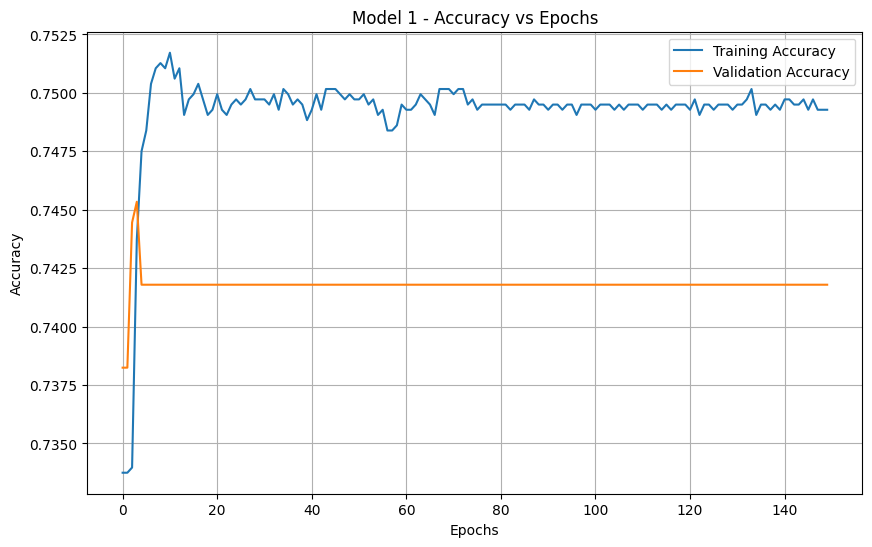

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    history1.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history1.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Model 1 - Accuracy vs Epochs")
plt.legend()
plt.grid(True)

plt.show()

#### Predictions

In [ ]:
y_pred_probability1 = model1.predict(X_test_scaled)

# Convert probability to 0/1
y_pred1 = (y_pred_probability1 >= 0.5).astype(int).ravel()

print("First 20 predictions:")
print(y_pred1[:20])

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


#### Model 1 — Confusion Matrix

In [ ]:
cm1 = confusion_matrix(y_test, y_pred1)

print("Model 1 Confusion Matrix:")
print(cm1)

Model 1 Confusion Matrix:
[[927 108]
 [216 158]]


#### Visualize Model 1 confusion matrix

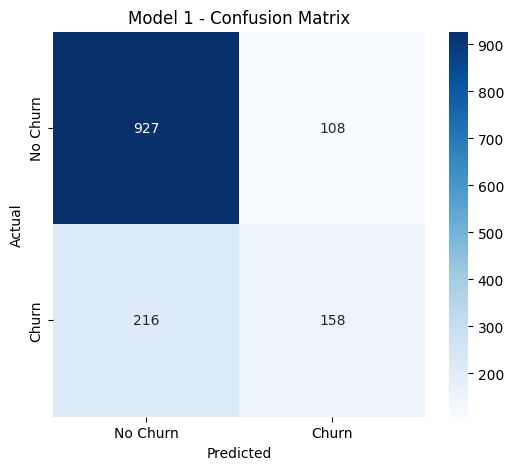

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm1,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Model 1 - Confusion Matrix")

plt.show()

#### Model 1 accuracy

In [ ]:
accuracy1 = accuracy_score(y_test, y_pred1)

print("Model 1 Test Accuracy:",
      round(accuracy1 * 100, 2), "%")

Model 1 Test Accuracy: 77.0 %


#### Model 1 classification report

In [ ]:
print(classification_report(
    y_test,
    y_pred1,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.81      0.90      0.85      1035
       Churn       0.59      0.42      0.49       374

    accuracy                           0.77      1409
   macro avg       0.70      0.66      0.67      1409
weighted avg       0.75      0.77      0.76      1409



#### MODEL 2 — WITH DROPOUT

#### Build Model 2

In [ ]:
model2 = Sequential([

    # Input/visible layer - 12 nodes
    Dense(
        12,
        activation="relu",
        input_shape=(X_train_scaled.shape[1],)
    ),

    # Dropout after input layer
    Dropout(0.3),

    # Hidden layer - 8 nodes
    Dense(
        8,
        activation="relu"
    ),

    # Dropout after hidden layer
    Dropout(0.2),

    # Output layer
    Dense(
        1,
        activation="sigmoid"
    )
])

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 12)             │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137 (548.00 B)

 Trainable params: 137 (548.00 B)

 Non-trainable params: 0 (0.00 B)

#### Compile Model 2

In [ ]:
model2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

#### Train Model 2

In [ ]:
history2 = model2.fit(
    X_train_scaled,
    y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

Epoch 1/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6947 - loss: 0.6283 - val_accuracy: 0.7382 - val_loss: 0.5621
Epoch 2/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7326 - loss: 0.5512 - val_accuracy: 0.7382 - val_loss: 0.5215
Epoch 3/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7335 - loss: 0.5411 - val_accuracy: 0.7382 - val_loss: 0.5190
Epoch 4/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7337 - loss: 0.5308 - val_accuracy: 0.7382 - val_loss: 0.5188
Epoch 5/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7335 - loss: 0.5266 - val_accuracy: 0.7382 - val_loss: 0.5178
Epoch 6/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7337 - loss: 0.5290 - val_accuracy: 0.7382 - val_loss: 0.5180
Epoch 7/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7382 - loss: 0.5250 - val_accuracy: 0.7382 - val_loss: 0.5178
Epoch 8/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7380 - loss: 0.5257 - val_accu

#### Accuracy vs Epochs

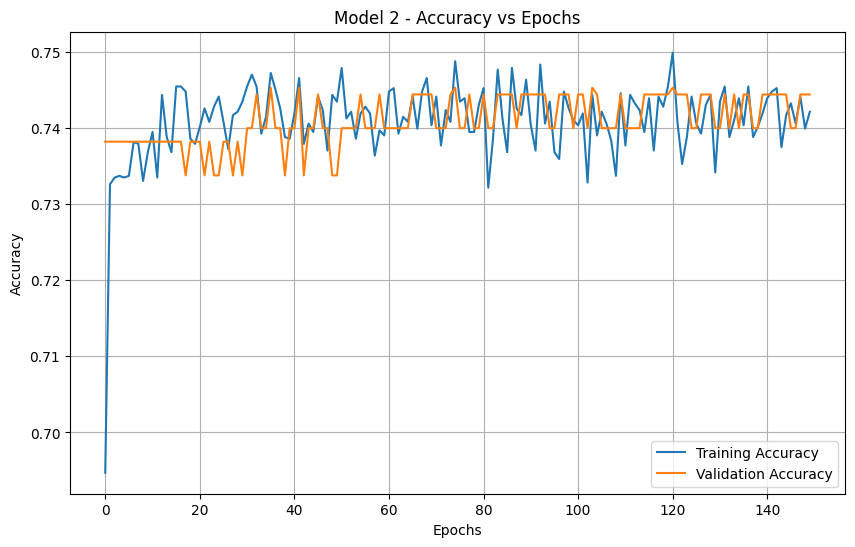

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    history2.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history2.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Model 2 - Accuracy vs Epochs")
plt.legend()
plt.grid(True)

plt.show()

#### Predictions

In [ ]:
y_pred_probability2 = model2.predict(X_test_scaled)

y_pred2 = (y_pred_probability2 >= 0.5).astype(int).ravel()

print("First 20 predictions:")
print(y_pred2[:20])

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


#### Model 2 — Confusion Matrix

In [ ]:
cm2 = confusion_matrix(y_test, y_pred2)

print("Model 2 Confusion Matrix:")
print(cm2)

Model 2 Confusion Matrix:
[[966  69]
 [263 111]]


#### Visualize Model 2 confusion matrix

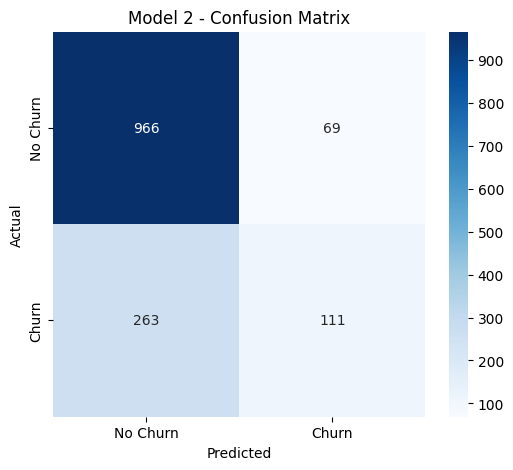

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm2,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Model 2 - Confusion Matrix")

plt.show()

#### Model 2 accuracy

In [ ]:
accuracy2 = accuracy_score(y_test, y_pred2)

print("Model 2 Test Accuracy:",
      round(accuracy2 * 100, 2), "%")

Model 2 Test Accuracy: 76.44 %


#### Model 2 classification report

In [ ]:
print(classification_report(
    y_test,
    y_pred2,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.79      0.93      0.85      1035
       Churn       0.62      0.30      0.40       374

    accuracy                           0.76      1409
   macro avg       0.70      0.62      0.63      1409
weighted avg       0.74      0.76      0.73      1409



#### MODEL 3

In [ ]:
features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

X3 = df[features]
y3 = df["Churn_Encoded"]

print("Features:")
print(X3.head())

print("\nTarget:")
print(y3.head())

Features:
   tenure  MonthlyCharges  TotalCharges
0       1           29.85         29.85
1      34           56.95       1889.50
2       2           53.85        108.15
3      45           42.30       1840.75
4       2           70.70        151.65

Target:
0    0
1    0
2    1
3    0
4    1
Name: Churn_Encoded, dtype: int64


#### Train/test split

In [ ]:
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3,
    y3,
    test_size=0.20,
    random_state=42,
    stratify=y3
)

print("Training data shape:", X3_train.shape)
print("Testing data shape:", X3_test.shape)

Training data shape: (5634, 3)
Testing data shape: (1409, 3)


#### Scale Model 3 features

In [ ]:
scaler3 = StandardScaler()

X3_train_scaled = scaler3.fit_transform(X3_train)
X3_test_scaled = scaler3.transform(X3_test)

print("Scaled training data:")
print(X3_train_scaled[:5])

Scaled training data:
[[ 0.10237124 -0.52197565 -0.26369549]
 [-0.71174346  0.33747781 -0.5050764 ]
 [-0.79315493 -0.80901319 -0.75132793]
 [-0.26398038  0.28438416 -0.17415945]
 [-1.28162375 -0.67627907 -0.99082202]]


#### Build Model 3

In [ ]:
model3 = Sequential([

    # Input/visible layer - 12 nodes
    Dense(
        12,
        activation="relu",
        input_shape=(X3_train_scaled.shape[1],)
    ),

    # Hidden layer - 8 nodes
    Dense(
        8,
        activation="relu"
    ),

    # Output layer
    Dense(
        1,
        activation="sigmoid"
    )
])

model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 12)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)

#### Compile Model 3

In [ ]:
model3.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

#### Train Model 3 for 150 epochs

In [ ]:
history3 = model3.fit(
    X3_train_scaled,
    y3_train,
    epochs=150,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

Epoch 1/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6838 - loss: nan - val_accuracy: 0.7382 - val_loss: nan
Epoch 2/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7337 - loss: nan - val_accuracy: 0.7382 - val_loss: nan
Epoch 3/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7337 - loss: nan - val_accuracy: 0.7382 - val_loss: nan
Epoch 4/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7337 - loss: nan - val_accuracy: 0.7382 - val_loss: nan
Epoch 5/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7337 - loss: nan - val_accuracy: 0.7382 - val_loss: nan
Epoch 6/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7337 - loss: nan - val_accuracy: 0.7382 - val_loss: nan
Epoch 7/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7337 - loss: nan - val_accuracy: 0.7382 - val_loss: nan
Epoch 8/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7337 - loss: nan - val_accuracy: 0.7382 - val_loss: nan
Epoch 9/150
141/

#### Accuracy vs Epochs

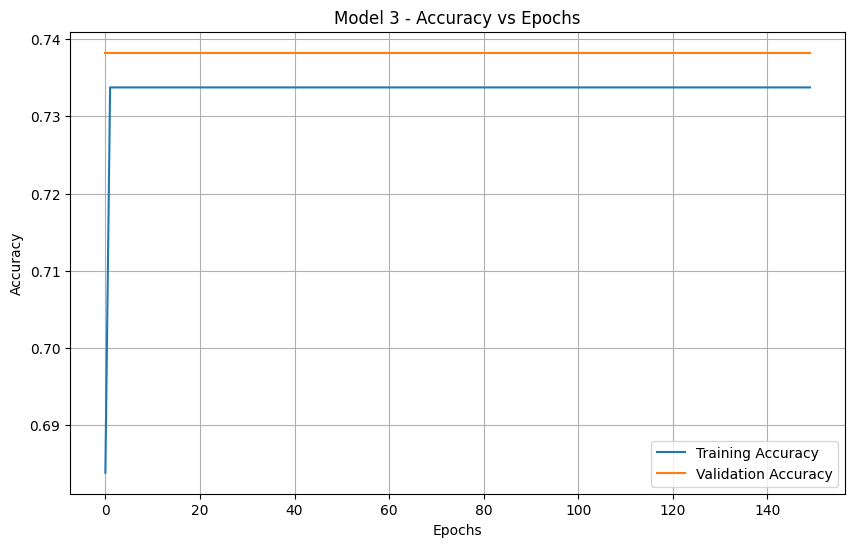

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    history3.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history3.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Model 3 - Accuracy vs Epochs")
plt.legend()
plt.grid(True)

plt.show()

#### Model 3 — Predictions

In [ ]:
y_pred_probability3 = model3.predict(X3_test_scaled)

y_pred3 = (y_pred_probability3 >= 0.5).astype(int).ravel()

print("First 20 predictions:")
print(y_pred3[:20])

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


#### Model 3 — Confusion Matrix

In [ ]:
cm3 = confusion_matrix(y3_test, y_pred3)

print("Model 3 Confusion Matrix:")
print(cm3)

Model 3 Confusion Matrix:
[[1035    0]
 [ 374    0]]


#### Visualize Model 3 confusion matrix

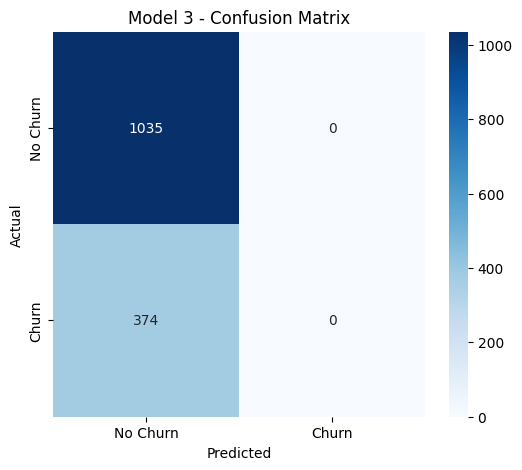

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm3,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Model 3 - Confusion Matrix")

plt.show()

#### Model 3 accuracy

In [ ]:
accuracy3 = accuracy_score(y3_test, y_pred3)

print("Model 3 Test Accuracy:",
      round(accuracy3 * 100, 2), "%")

Model 3 Test Accuracy: 73.46 %


#### Model 3 classification report

In [ ]:
print(classification_report(
    y3_test,
    y_pred3,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.73      1.00      0.85      1035
       Churn       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409



#### FINAL — Compare all 3 models

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Model 1 - Tenure",
        "Model 2 - Tenure + Dropout",
        "Model 3 - 3 Features"
    ],

    "Test Accuracy": [
        accuracy1,
        accuracy2,
        accuracy3
    ]
})

results["Accuracy (%)"] = results["Test Accuracy"] * 100

results

,Model,Test Accuracy,Accuracy (%)
0,Model 1 - Tenure,0.770050,77.004968
1,Model 2 - Tenure + Dropout,0.764372,76.437189
2,Model 3 - 3 Features,0.734564,73.456352


#### Plot model comparison

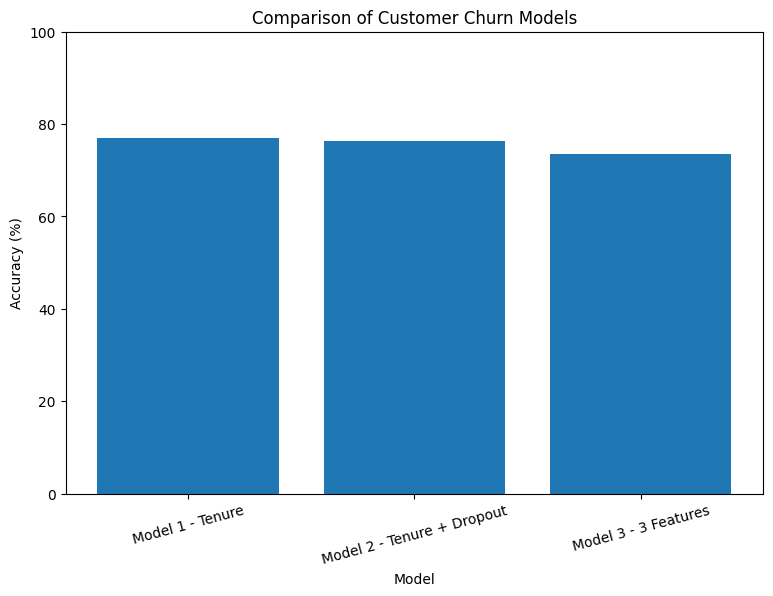

In [ ]:
plt.figure(figsize=(9, 6))

plt.bar(
    results["Model"],
    results["Accuracy (%)"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Comparison of Customer Churn Models")

plt.xticks(rotation=15)
plt.ylim(0, 100)

plt.show()

#### Save the best model

In [ ]:
best_model_index = results["Test Accuracy"].idxmax()
best_model_name = results.loc[best_model_index, "Model"]

print("Best Model:", best_model_name)

if best_model_name == "Model 1 - Tenure":
    model1.save("customer_churn_model1.keras")

elif best_model_name == "Model 2 - Tenure + Dropout":
    model2.save("customer_churn_model2.keras")

else:
    model3.save("customer_churn_model3.keras")

print("Best model saved successfully.")

Best Model: Model 1 - Tenure
Best model saved successfully.


#### One-cell version for the final model

In [ ]:
model3 = Sequential([
    Dense(12, activation="relu", input_shape=(3,)),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

model3.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history3 = model3.fit(
    X3_train_scaled,
    y3_train,
    epochs=150,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

y_pred3 = (model3.predict(X3_test_scaled) >= 0.5).astype(int).ravel()

print("Accuracy:",
      accuracy_score(y3_test, y_pred3))

print("\nConfusion Matrix:")
print(confusion_matrix(y3_test, y_pred3))

print("\nClassification Report:")
print(classification_report(
    y3_test,
    y_pred3,
    target_names=["No Churn", "Churn"]
))

Epoch 1/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7337 - loss: nan - val_accuracy: 0.7382 - val_loss: nan
Epoch 2/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7337 - loss: nan - val_accuracy: 0.7382 - val_loss: nan
Epoch 3/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7337 - loss: nan - val_accuracy: 0.7382 - val_loss: nan
Epoch 4/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7337 - loss: nan - val_accuracy: 0.7382 - val_loss: nan
Epoch 5/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7337 - loss: nan - val_accuracy: 0.7382 - val_loss: nan
Epoch 6/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7337 - loss: nan - val_accuracy: 0.7382 - val_loss: nan
Epoch 7/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7337 - loss: nan - val_accuracy: 0.7382 - val_loss: nan
Epoch 8/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7337 - loss: nan - val_accuracy: 0.7382 - val_loss: nan
Epoch 9/150
141